In [2]:
import pandas as pd
from IPython.terminal.shortcuts.filters import eval_node
from scipy.stats import kendalltau, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/node_data.csv')

In [3]:
df.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')

In [16]:
df.head()

,node,community,degree,local_closeness,global_closeness,local_core_num,global_core_num,betweenness,eigenvector,trussness,local_zscore,local_P,local_role,global_role
0,0,c0,0.085934,0.980337,0.353343,21,21,1.573126e-01,3.391796e-05,76,0.734058,0.028519,Local Ultra-Peripheral,NaN
1,1,c0,0.004210,0.507267,0.261376,13,13,3.119848e-06,6.045346e-07,18,-0.352420,0.000000,Local Ultra-Peripheral,NaN
2,2,c0,0.002476,0.502158,0.261258,9,9,3.096359e-07,2.233461e-07,11,-0.375821,0.000000,Local Ultra-Peripheral,Global Peripheral
3,3,c0,0.004210,0.507267,0.261376,13,13,4.816558e-06,6.635648e-07,17,-0.352420,0.000000,Local Ultra-Peripheral,NaN
4,4,c0,0.002476,0.502158,0.261258,9,9,0.000000e+00,2.236416e-07,10,-0.375821,0.000000,Local Ultra-Peripheral,Global Peripheral


In [17]:
cols = list(df.columns)

In [18]:
remove = ["node", "community", "global_role", "local_role"]
metrics = [c for c in cols if c not in remove]
print(metrics)

['degree', 'local_closeness', 'global_closeness', 'local_core_num', 'global_core_num', 'betweenness', 'eigenvector', 'trussness', 'local_zscore', 'local_P']


In [19]:
results = []

In [20]:
count = 0
for i, col_a in enumerate(metrics):
    for col_b in metrics[i+1:]:
        count += 1

        print(f'col_a: {col_a} || col_b: {col_b}')

        x = df[col_a]
        y = df[col_b]

        tau, _ = kendalltau(x, y)
        rho, _ = spearmanr(x, y)

        results.append({
            "metric_a": col_a,
            "metric_b": col_b,
            "kendall_tau": tau,
            "spearman_rho": rho
        })

# Checking if this iterates for every possible pair, expecting 45 (number of possible pairs in a group of 10).
#print(f'Number of pairs: {count}')

eval_df = pd.DataFrame(results)

col_a: degree || col_b: local_closeness
col_a: degree || col_b: global_closeness
col_a: degree || col_b: local_core_num
col_a: degree || col_b: global_core_num
col_a: degree || col_b: betweenness
col_a: degree || col_b: eigenvector
col_a: degree || col_b: trussness
col_a: degree || col_b: local_zscore
col_a: degree || col_b: local_P
col_a: local_closeness || col_b: global_closeness
col_a: local_closeness || col_b: local_core_num
col_a: local_closeness || col_b: global_core_num
col_a: local_closeness || col_b: betweenness
col_a: local_closeness || col_b: eigenvector
col_a: local_closeness || col_b: trussness
col_a: local_closeness || col_b: local_zscore
col_a: local_closeness || col_b: local_P
col_a: global_closeness || col_b: local_core_num
col_a: global_closeness || col_b: global_core_num
col_a: global_closeness || col_b: betweenness
col_a: global_closeness || col_b: eigenvector
col_a: global_closeness || col_b: trussness
col_a: global_closeness || col_b: local_zscore
col_a: global_cl

In [21]:
eval_df.head(10)

,metric_a,metric_b,kendall_tau,spearman_rho
0,degree,local_closeness,0.612028,0.746028
1,degree,global_closeness,0.310740,0.411140
2,degree,local_core_num,0.869639,0.970683
3,degree,global_core_num,0.878919,0.973002
4,degree,betweenness,0.491376,0.669765
5,degree,eigenvector,0.482472,0.636423
6,degree,trussness,0.985043,0.997664
7,degree,local_zscore,0.293625,0.352542
8,degree,local_P,0.163331,0.272955
9,local_closeness,global_closeness,0.059332,0.025747


In [22]:
eval_df.to_dict(orient='records')

[{'metric_a': 'degree',
  'metric_b': 'local_closeness',
  'kendall_tau': 0.6120278658609827,
  'spearman_rho': 0.746027926856969},
 {'metric_a': 'degree',
  'metric_b': 'global_closeness',
  'kendall_tau': 0.3107399656371182,
  'spearman_rho': 0.4111400791449604},
 {'metric_a': 'degree',
  'metric_b': 'local_core_num',
  'kendall_tau': 0.8696386492845485,
  'spearman_rho': 0.9706828455961832},
 {'metric_a': 'degree',
  'metric_b': 'global_core_num',
  'kendall_tau': 0.878918739981324,
  'spearman_rho': 0.9730020936180407},
 {'metric_a': 'degree',
  'metric_b': 'betweenness',
  'kendall_tau': 0.49137559619511567,
  'spearman_rho': 0.6697647678706609},
 {'metric_a': 'degree',
  'metric_b': 'eigenvector',
  'kendall_tau': 0.48247211893486086,
  'spearman_rho': 0.6364232560276092},
 {'metric_a': 'degree',
  'metric_b': 'trussness',
  'kendall_tau': 0.9850425582971478,
  'spearman_rho': 0.9976642076166495},
 {'metric_a': 'degree',
  'metric_b': 'local_zscore',
  'kendall_tau': 0.2936245311

In [3]:
eval_df = pd.read_csv('../data/processed/rank_corr_eval.csv')

In [ ]:
eval_df

In [5]:
spearman_matrix = eval_df.pivot(index="metric_a", columns="metric_b", values="spearman_rho")
#spearman_matrix

In [6]:
kendall_matrix = eval_df.pivot(index="metric_a", columns="metric_b", values="kendall_tau")
#kendall_matrix

In [7]:
spearman_matrix = spearman_matrix.combine_first(spearman_matrix.T)
spearman_matrix = spearman_matrix.fillna(1)
#spearman_matrix

In [8]:
kendall_matrix = kendall_matrix.combine_first(kendall_matrix.T)
kendall_matrix = kendall_matrix.fillna(1)
#kendall_matrix

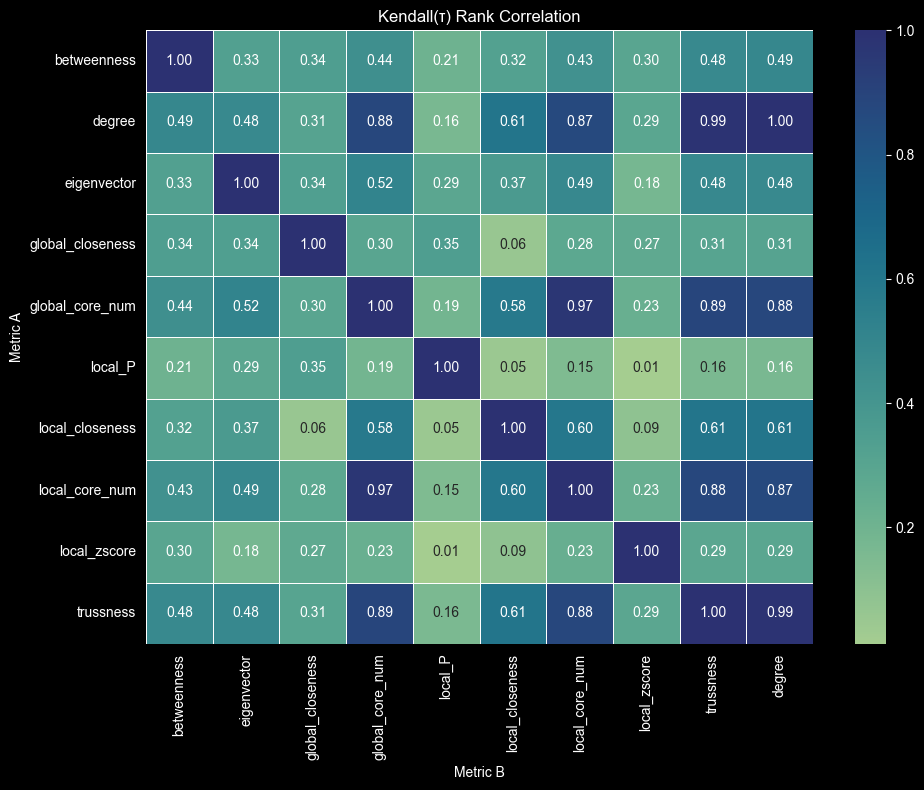

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(kendall_matrix, annot=True, ax=ax, fmt=".2f", linewidth=.5, cmap='crest')
ax.set_title('Kendall(τ) Rank Correlation')
ax.set_ylabel('Metric A')
ax.set_xlabel('Metric B')
plt.tight_layout()
#fig.savefig('../data/diagrams/kendall_heatmap.png')
plt.show()

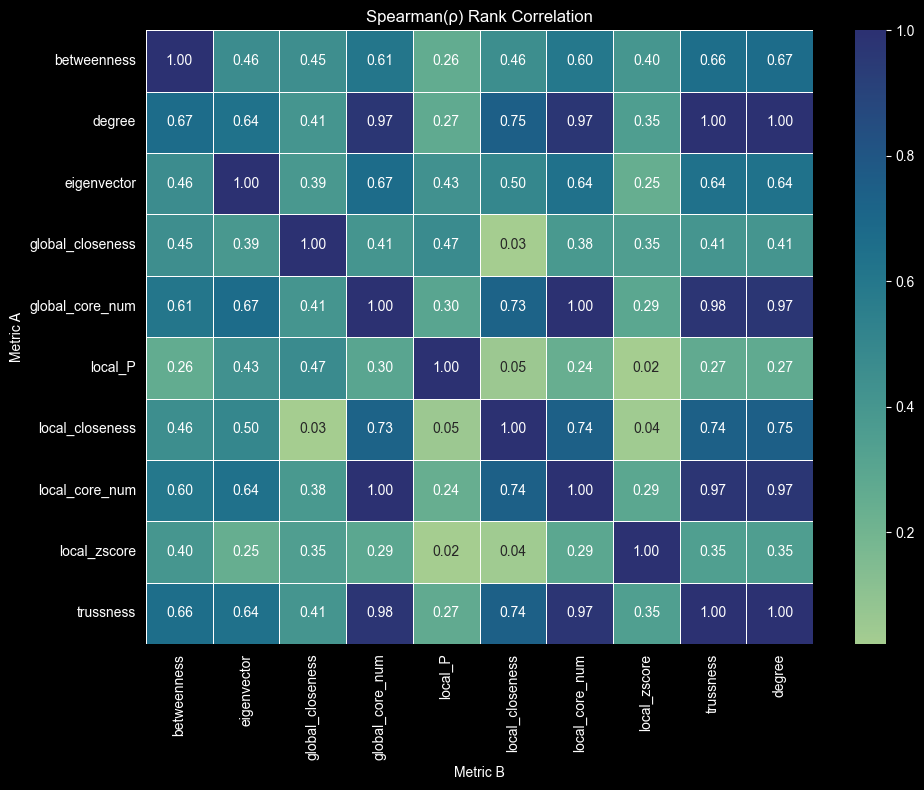

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(spearman_matrix, annot=True, ax=ax, fmt=".2f", linewidth=.5, cmap='crest')
ax.set_title('Spearman(ρ) Rank Correlation')
ax.set_ylabel('Metric A')
ax.set_xlabel('Metric B')
plt.tight_layout()
fig.savefig('../data/diagrams/spearman_heatmap.png')
plt.show()